# Unidade VI — Análise de Grupos

## Métodos baseados em grade

**Carga estimada:** 1 hora  
**Pré-requisitos:** atributos numéricos, densidade, DBSCAN e visualização bidimensional.

> **Pergunta norteadora:** como substituir operações sobre muitos objetos por operações sobre células resumidas do espaço?

Métodos baseados em grade quantizam o espaço, calculam resumos por célula e formam regiões a partir das células relevantes. Essa escolha favorece escalabilidade, mas introduz efeitos de resolução e fronteira.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- explicar quantização e densidade de células;
- conectar células densas para formar regiões;
- analisar resolução, limiar, cobertura e alinhamento;
- distinguir a busca em subespaços do CLIQUE;
- explicar a grade hierárquica multirresolução do STING;
- comparar grade e DBSCAN quanto a unidade de processamento e limitações.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from sklearn.datasets import make_moons

RANDOM_STATE = 42

## 1. Quantização, densidade e conexão

A ideia básica é substituir operações repetidas sobre objetos por operações sobre **células**:

1. dividir cada dimensão em intervalos e formar uma grade;
2. contar ou resumir os objetos de cada célula;
3. identificar células densas segundo um limiar;
4. conectar células densas vizinhas para formar regiões.

O custo após a construção dos resumos pode depender mais do número de células que do número de objetos. Em troca, a resposta depende da resolução, do alinhamento da grade e do limiar de densidade. Em muitas dimensões, a quantidade de células possíveis cresce rapidamente.

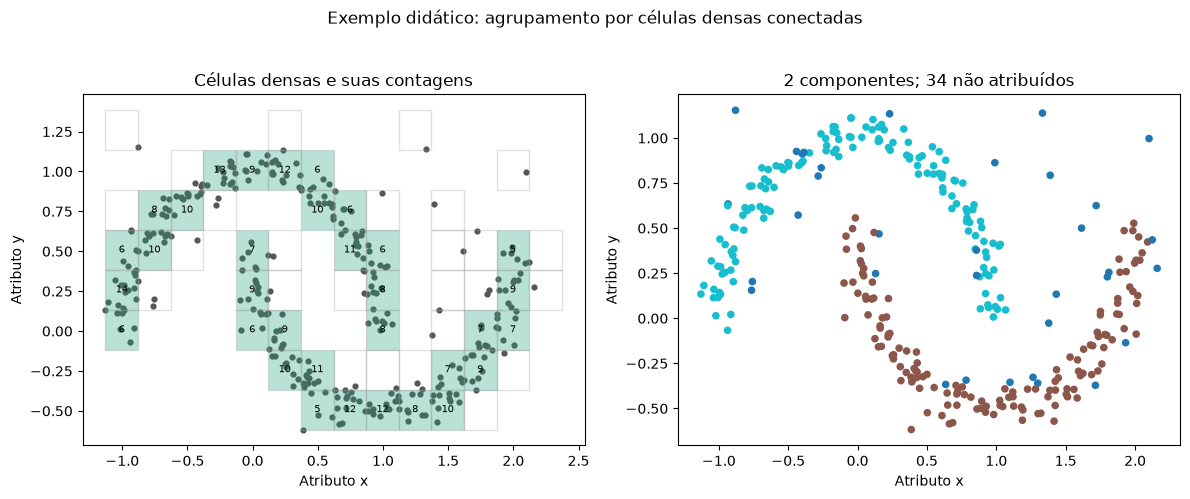

In [2]:
def agrupar_por_grade(X, largura=0.25, contagem_minima=4):
    origem = X.min(axis=0) - 1e-9
    celulas = np.floor((X - origem) / largura).astype(int)
    contagens = Counter(map(tuple, celulas))
    densas = {c for c, n in contagens.items() if n >= contagem_minima}
    componente, proximo = {}, 0
    for inicio in densas:
        if inicio in componente: continue
        pilha, componente[inicio] = [inicio], proximo
        while pilha:
            atual = pilha.pop()
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    vizinha = (atual[0] + dx, atual[1] + dy)
                    if vizinha in densas and vizinha not in componente:
                        componente[vizinha] = proximo
                        pilha.append(vizinha)
        proximo += 1
    labels = np.array([componente.get(tuple(c), -1) for c in celulas])
    return labels, contagens, densas, origem

X_luas, _ = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)
X_grade = np.vstack([X_luas, rng.uniform([-1.2, -0.7], [2.2, 1.2], size=(20, 2))])
largura, minimo = 0.25, 4
labels_grade, contagens, densas, origem = agrupar_por_grade(X_grade, largura, minimo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(X_grade[:, 0], X_grade[:, 1], s=12, color="#555555")
for celula, n in contagens.items():
    xy = origem + largura * np.array(celula)
    axes[0].add_patch(Rectangle(xy, largura, largura, facecolor="#1b9e77" if celula in densas else "none", edgecolor="#999999", alpha=0.30))
    if n >= minimo: axes[0].text(xy[0] + largura/2, xy[1] + largura/2, str(n), ha="center", va="center", fontsize=7)
axes[0].set(title="Células densas e suas contagens", xlabel="Atributo x", ylabel="Atributo y")
axes[1].scatter(X_grade[:, 0], X_grade[:, 1], c=labels_grade, cmap="tab10", s=20)
axes[1].set(title=f"{len(set(labels_grade) - {-1})} componentes; {(labels_grade == -1).sum()} não atribuídos", xlabel="Atributo x", ylabel="Atributo y")
fig.suptitle("Exemplo didático: agrupamento por células densas conectadas", y=1.03)
fig.tight_layout()
plt.show()

## 2. CLIQUE e STING: duas maneiras de explorar a grade

- **CLIQUE** procura células densas também em subespaços. Usa uma propriedade monotônica semelhante à do Apriori: uma célula densa em várias dimensões só pode existir se suas projeções de menor dimensão também forem densas. É útil quando grupos aparecem apenas em subconjuntos dos atributos.
- **STING** mantém uma grade hierárquica com várias resoluções. Cada célula armazena resumos como contagem, média, desvio, mínimo e máximo. Consultas descem apenas por regiões relevantes, favorecendo processamento incremental e paralelo.

O código anterior é uma ilustração autoral da ideia de células densas conectadas, não uma implementação completa de CLIQUE ou STING.

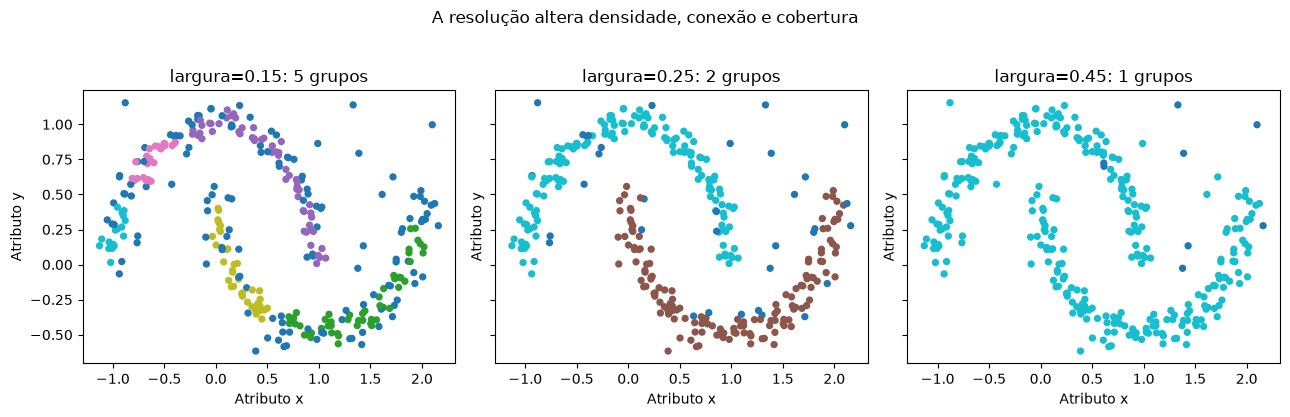

,largura,células densas,grupos,cobertura
0,0.15,36,5,0.578
1,0.25,33,2,0.894
2,0.45,20,1,0.975


In [3]:
larguras = [0.15, 0.25, 0.45]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
resumo_grade = []
for ax, w in zip(axes, larguras):
    labels, _, densas_w, _ = agrupar_por_grade(X_grade, largura=w, contagem_minima=minimo)
    grupos = len(set(labels) - {-1})
    cobertura = np.mean(labels != -1)
    resumo_grade.append({"largura": w, "células densas": len(densas_w), "grupos": grupos, "cobertura": cobertura})
    ax.scatter(X_grade[:, 0], X_grade[:, 1], c=labels, cmap="tab10", s=18)
    ax.set(title=f"largura={w}: {grupos} grupos", xlabel="Atributo x", ylabel="Atributo y")
fig.suptitle("A resolução altera densidade, conexão e cobertura", y=1.03)
fig.tight_layout()
plt.show()
display(pd.DataFrame(resumo_grade).round(3))

## 3. Grade e DBSCAN

DBSCAN calcula vizinhanças em torno dos objetos; métodos de grade resumem primeiro o espaço e operam sobre células. Ambos podem representar regiões densas, mas a grade adiciona uma resolução e fronteiras fixas.

Grades podem oferecer consultas e atualizações eficientes, especialmente em estruturas multirresolução. Em contrapartida, células grossas podem fundir regiões e células finas podem fragmentá-las. A origem da grade e a alta dimensionalidade também precisam ser avaliadas.

## 4. Atividades

**U06-NB05-V01.** Uma grade possui células densas (0,0), (0,1), (1,1), (5,5) e (5,6). Considerando vizinhança de oito direções, quantos grupos conectados existem e quais células pertencem a cada um?

**U06-NB05-E01.** Explique o efeito provável de tornar a grade muito fina ou muito grossa. Relacione sua resposta a fragmentação, cobertura, fronteiras e custo.

**U06-NB05-E02.** Um sistema geoespacial recebe milhões de pontos por hora e precisa responder consultas em diferentes escalas. Compare DBSCAN, PAM e STING e proponha uma arquitetura inicial, incluindo uma limitação a monitorar.

## 5. Síntese

- A grade quantiza o espaço e resume objetos em células.
- Células densas conectadas podem formar grupos de diferentes formatos.
- CLIQUE procura densidade em subespaços; STING organiza resumos em múltiplas resoluções.
- Resolução, limiar e origem da grade alteram fragmentação, fusão e cobertura.
- O ganho de escalabilidade não elimina a necessidade de avaliar qualidade e utilidade.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seção 8.4.3.

Os dados, a implementação didática e as figuras são autorais e produzidos localmente. O exemplo não é uma implementação completa de CLIQUE ou STING.